### Graph 1

In [36]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [37]:
class AgentState(TypedDict):
    msg : str

In [38]:
def greeting_node(state : AgentState) -> AgentState: # state as a input and state as a output
    state['msg'] = "Hello, World!"
    return state # we want to pass to the next node as well

In [39]:
graph = StateGraph(AgentState) # passing schema which we already define in the AgentState
graph.add_node("hello world", greeting_node) 
graph.set_entry_point("hello world") # mandatory for every graph, we pass the node name from where the execution would start.
graph.set_finish_point("hello world") # mandatory for every graph
app = graph.compile()

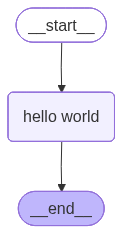

In [40]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [41]:
app.invoke({
    "msg" : "Hello"
})

{'msg': 'Hello, World!'}

### Graph 2

In [42]:
class AgentState(TypedDict):
    name : str
    age : int
    marks : List[int]
    msg : str

In [43]:
def calculation(state : AgentState) -> AgentState:
    
    state['msg'] = f"Hi {state['name']}, your age is {state['age']} and sum is {sum(state['marks'])}"

    return state
    

In [ ]:
graph = StateGraph(AgentState)
graph.add_node("sum_of_values", calculation) 
graph.set_entry_point("sum_of_values") 
graph.set_finish_point("sum_of_values") 
app = graph.compile()

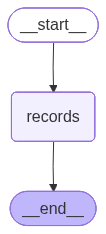

In [45]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [50]:
result = app.invoke(
    # {'name': 'Amandeep', 'age': 22, 'marks': [100, 100, 100], 'msg': ''}
    {'name': 'Amandeep', 'age': 22, 'marks': [100, 100, 100]}
)
result
result['msg']

'Hi Amandeep, your age is 22 and sum is 300'

### Graph 3

In [54]:
class AgentState(TypedDict):
    name : str
    age : int
    msg : str

In [56]:
def greeting(state : AgentState) -> AgentState:
    s1 = f"Hi {state['name']}, How are you?"
    state['msg'] = s1
    return state

def greeting_age(state : AgentState) -> AgentState:
    state['msg'] = state['msg'] + f"Your age is {state['age']}"
    return state

In [57]:
graph = StateGraph(AgentState)
graph.add_node("node1", greeting) 
graph.add_node("node2", greeting_age)
graph.add_edge("node1", "node2") 
graph.set_entry_point("node1") 
graph.set_finish_point("node2") 
app = graph.compile()

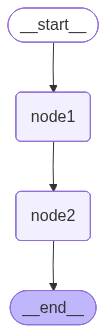

In [58]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [59]:
app.invoke({
    'name' : 'Amandeep Singh',
    'age' : 22
})

{'name': 'Amandeep Singh',
 'age': 22,
 'msg': 'Hi Amandeep Singh, How are you?Your age is 22'}